Shape: (583, 92)
Rows: 583, Columns: 92
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 's

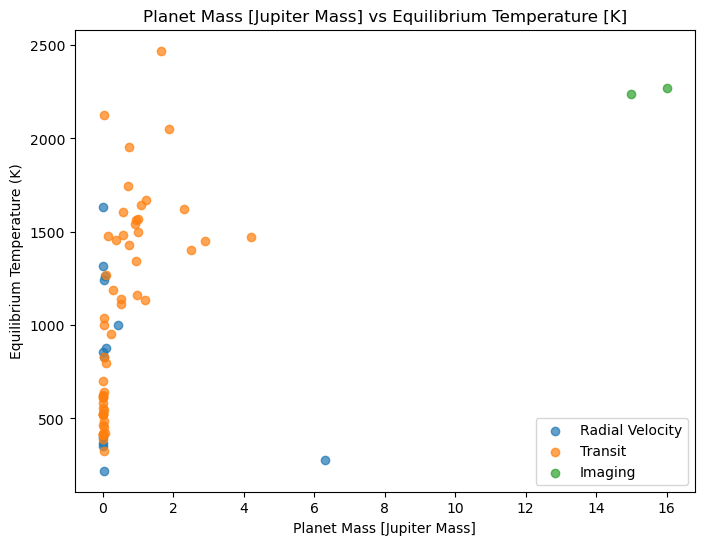

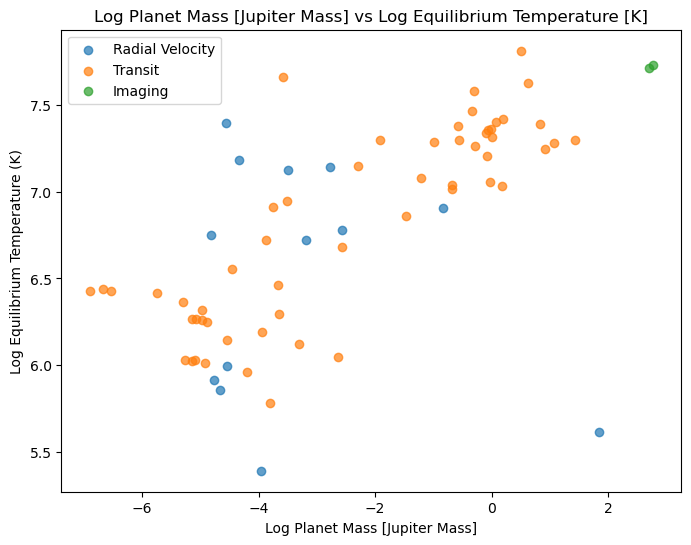

Planets found by imaging are more likely to be massive.
Coldest planet with a mass larger than 5 jupiter masses:
Name: eps Ind A b
Index: 581
Temperature: 275.0
Mass: 6.31
Star Type: K5 V


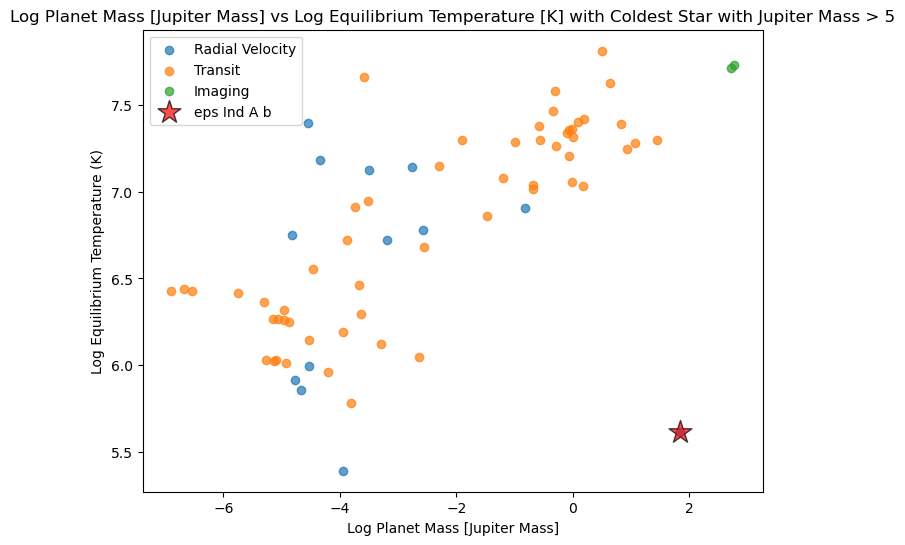

Title: A temperate super-Jupiter imaged with JWST in the mid-infrared
        
Abstract Summary: Astronomers used the JWST to directly image a giant exoplanet orbiting near the sun Epsilon Indi A. This confirmed a planet hinted at by an ealier indirect measurement but with very different properties. This does match the exoplanet.


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("exoplanet_data.csv", comment = "#")
print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(list(df.columns))
print(f"Columns I don't know: [sy_snum, sy_pnum, pl_orbper, pl_rade, pl_orbeccen]")
# Table Label                 | Database Column Name | Description
# Planet Name                 | pl_name              | full name of exoplanet
# Host Name                   | hostname             | name of star the exoplanet orbits
# Discovery Method            | discoverymethod      | method used to find the planet
# Spectral Type               | st_spectype          | classification of host star
# Equilibrium Temperature [K] | pl_eqt               | temperature of planet in Kelvin
# Planet Mass [Jupiter Mass]  | pl_bmassj            | best mass estimate in Jupiter masses
df = df[["pl_name", "hostname", "discoverymethod", "st_spectype", "pl_eqt", "pl_bmassj"]]
df = df.dropna()
print(f"Shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
print(f"First 5: \n {df.head(5)}")
print(f"Last 5: \n {df.tail(5)}")
print(list(df.columns))
print(f"Discovery Methods: {df["discoverymethod"].value_counts()}")
print(f"Method Definitions: \nTransit (most): observing a star's brightness dip as a planet passes in front of it \nRadial Velocity: measuring the wobble of a star caused by a planet's gravity \nImaging (least): taking a picture of the planet")

plt.figure(figsize = (8, 6))
for method in df["discoverymethod"].unique():
    subset = df[df["discoverymethod"] == method]
    plt.scatter(subset["pl_bmassj"], subset["pl_eqt"], label = method, alpha = 0.7)
plt.title("Planet Mass [Jupiter Mass] vs Equilibrium Temperature [K]")
plt.xlabel("Planet Mass [Jupiter Mass]")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()

plt.figure(figsize = (8, 6))
for method in df["discoverymethod"].unique():
    subset = df[df["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label = method, alpha = 0.7)
plt.title("Log Planet Mass [Jupiter Mass] vs Log Equilibrium Temperature [K]")
plt.xlabel("Log Planet Mass [Jupiter Mass]")
plt.ylabel("Log Equilibrium Temperature (K)")
plt.legend()
plt.show()

print("Planets found by imaging are more likely to be massive.")
big_enough = df[df["pl_bmassj"] > 5]
coldest_i = big_enough["pl_eqt"].idxmin()
coldest_planet = big_enough.loc[coldest_i]
print("Coldest planet with a mass larger than 5 jupiter masses:")
print(f"Name: {coldest_planet["pl_name"]}")
print(f"Index: {coldest_i}")
print(f"Temperature: {coldest_planet["pl_eqt"]}")
print(f"Mass: {coldest_planet["pl_bmassj"]}")
print(f"Star Type: {coldest_planet["st_spectype"]}")

plt.figure(figsize = (8, 6))
for method in df["discoverymethod"].unique():
    subset = df[df["discoverymethod"] == method]
    plt.scatter(np.log(subset["pl_bmassj"]), np.log(subset["pl_eqt"]), label = method, alpha = 0.7)
plt.scatter(np.log(coldest_planet["pl_bmassj"]), np.log(coldest_planet["pl_eqt"]), color = "red", marker = "*", s = 300, edgecolor = "black", label = coldest_planet["pl_name"], alpha = 0.7)
plt.title("Log Planet Mass [Jupiter Mass] vs Log Equilibrium Temperature [K] with Coldest Star with Jupiter Mass > 5")
plt.xlabel("Log Planet Mass [Jupiter Mass]")
plt.ylabel("Log Equilibrium Temperature (K)")
plt.legend()
plt.show()

print("""Title: A temperate super-Jupiter imaged with JWST in the mid-infrared
        \nAbstract Summary: Astronomers used the JWST to directly image a giant exoplanet orbiting near the sun Epsilon Indi A. This confirmed a planet hinted at by an ealier indirect measurement but with very different properties. This does match the exoplanet.""")